<a href="https://colab.research.google.com/github/joseph2022/Disease-Prediction/blob/main/Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DISEASE PREDICTION

In [35]:
!git clone https://github.com/joseph2022/Disease-Prediction.git
%cd Disease-Prediction


Cloning into 'Disease-Prediction'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 16.50 KiB | 16.50 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/Disease-Prediction/Disease-Prediction


In [36]:
!mv /content/Disease_Prediction.ipynb /content/Disease-Prediction/


mv: cannot stat '/content/Disease_Prediction.ipynb': No such file or directory


In [37]:
!pwd


/content/Disease-Prediction/Disease-Prediction


In [38]:
!touch Disease_Prediction.ipynb

In [39]:
!ls

Disease_Prediction.ipynb  README.md


In [40]:
!git add Disease_Prediction.ipynb

In [41]:
!git commit -m "Day 1: Created project notebook inside repository"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [42]:
!git config --global user.name "Joseph S Ottathil"
!git config --global user.email "josephsottathil@gmail.com"

In [43]:
!git config --global user.name
!git config --global user.email

Joseph S Ottathil
josephsottathil@gmail.com


In [44]:
!git add .
!git commit -m "Day 1: Created project notebook inside repository"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [45]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [46]:
# load dataset
data=pd.read_csv('/content/drive/MyDrive/Disease_Prediction/heart_disease.csv')
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [47]:
data.shape # returns the number of rows and columns(dimensions of the dataframe)

(10000, 21)

In [48]:
data.dtypes

,0
Age,float64
Gender,object
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,object
Smoking,object
Family Heart Disease,object
Diabetes,object
BMI,float64
High Blood Pressure,object


In [49]:
data.isna().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [50]:
# Dropped Alcohol Consumption due to high missing value
data=data.drop('Alcohol Consumption',axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,No,Yes,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,No,Yes,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,Yes,Yes,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,No,Yes,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Stress Level          9978 non-null   object 
 13  Sleep Hours           9975 non-null   float64
 14  Sugar Consumption     9970 non-null   object 
 15  Triglyceride Level  

In [52]:
data.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [53]:
data.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


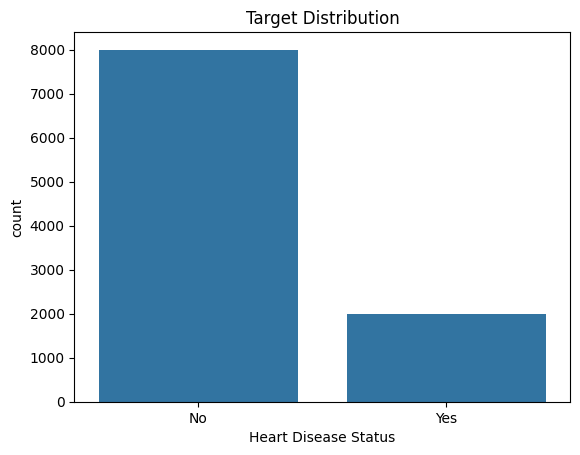

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


In [54]:

sns.countplot(x='Heart Disease Status',data=data)
plt.title('Target Distribution')
plt.show()
print(data["Heart Disease Status"].value_counts())

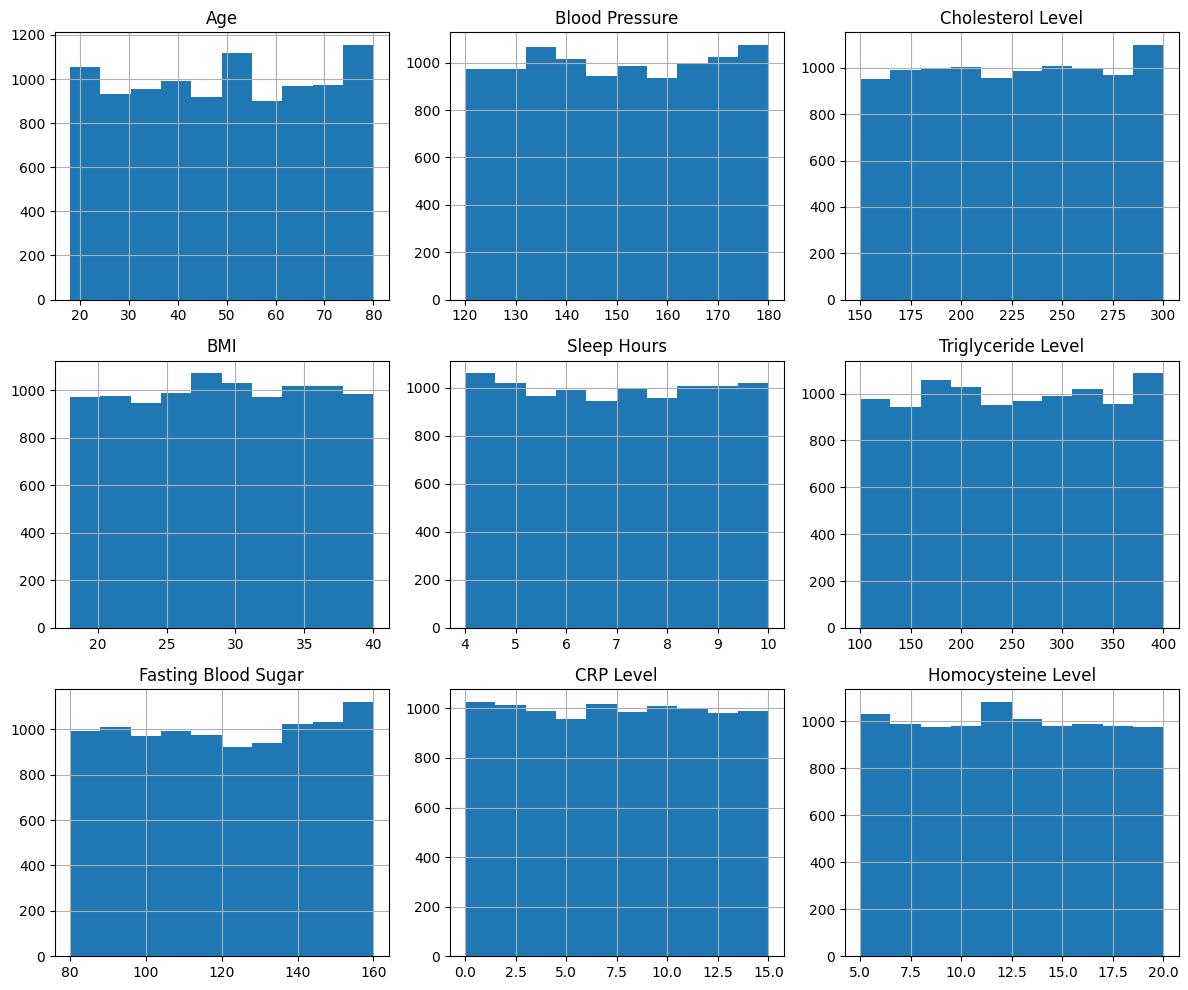

In [55]:
data.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

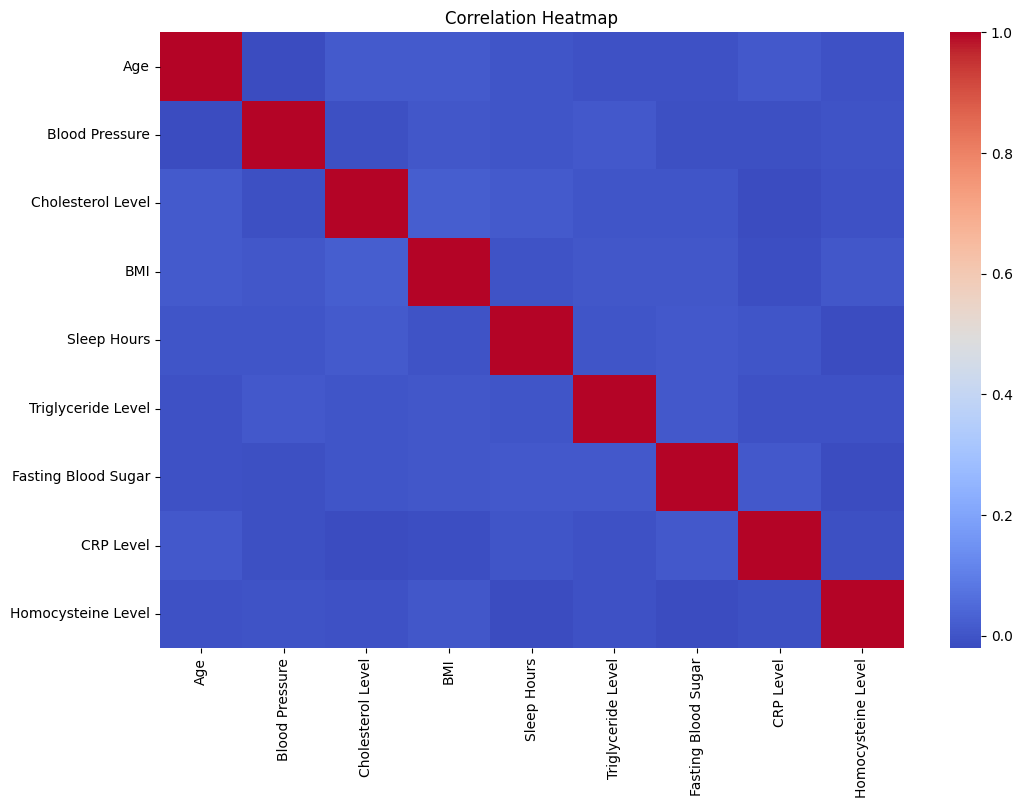

In [56]:
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=['int64','float64']).corr(),
            annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [57]:
# a=data.Age.mean() # Another method
# a

In [58]:
#ata.Age=data.Age.fillna(a)

In [59]:
# identify numerical,categorical columns
numerical_cols=data.select_dtypes(include=['int64','float64']).columns
categorical_cols=data.select_dtypes(include=['object']).columns

# fill numerical columns with median, we can also do it with mean and also mode too.
for col in numerical_cols:
  data[col]=data[col].fillna(data[col].median())

# fill categorical columns with median, we can also do it with mean and also mode too.
for col in categorical_cols:
  data[col]=data[col].fillna(data[col].mode()[0])

data.isna().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


In [60]:
data.dtypes

,0
Age,float64
Gender,object
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,object
Smoking,object
Family Heart Disease,object
Diabetes,object
BMI,float64
High Blood Pressure,object


In [61]:
label_encoder =preprocessing.LabelEncoder()
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

In [62]:
data.dtypes

,0
Age,float64
Gender,int64
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,int64
Smoking,int64
Family Heart Disease,int64
Diabetes,int64
BMI,float64
High Blood Pressure,int64
